In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from torch import nn
import numpy as np

In [2]:
df = pd.read_csv("08-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [5]:
df.describe()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
count,400.000000,4.000000e+02,400.000000
mean,0.000000,8.881784e-18,0.500000
std,7.719350,1.751650e+00,0.500626
min,-9.999954,-3.000000e+00,0.000000
25%,-6.134779,-1.500000e+00,0.000000
50%,0.000000,0.000000e+00,0.500000
75%,6.134779,1.500000e+00,1.000000
max,9.999954,3.000000e+00,1.000000


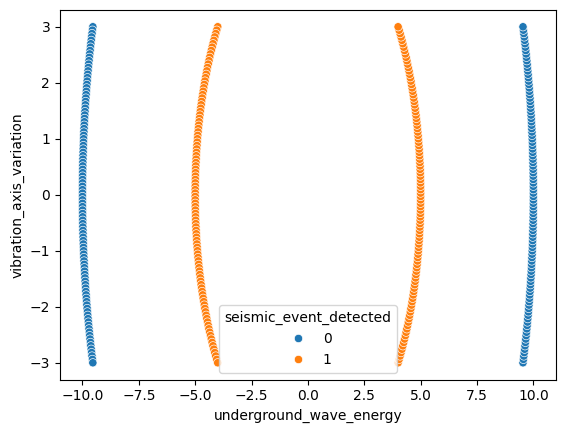

In [6]:
sns.scatterplot(x=df["underground_wave_energy"], y=df["vibration_axis_variation"], hue=df["seismic_event_detected"])
plt.show()

In [7]:
X = df[["underground_wave_energy", "vibration_axis_variation"]].values
y = df["seismic_event_detected"].values

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
len(X_train), len(X_test), len(y_train), len(y_test)

(320, 80, 320, 80)

In [10]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [11]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([320, 2]) torch.Size([320, 1])
torch.Size([80, 2]) torch.Size([80, 1])


In [12]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [13]:
model = ClassificationModel()

In [14]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [15]:
def calculate_accuracy(y_test, y_pred):
    correct = torch.eq(y_test, y_pred).sum().item()
    accuracy = (correct / len(y_pred)) * 100 
    return accuracy

In [16]:
torch.manual_seed(42)
epochs = 400

for epoch in range(epochs):
    model.train()
    
    y_logits = model(X_train) 
    y_pred = torch.round(torch.sigmoid(y_logits))
  
    loss = loss_fn(y_logits, y_train) 
    acc = calculate_accuracy(y_test=y_train, y_pred=y_pred) 
    
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))
  
        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test=y_test, y_pred=test_pred)

    if epoch % 40 == 0:
        print(f"Epoch: {epoch} Loss: {loss}, Accuracy: {acc} Test loss: {test_loss}, Test acc: {test_acc}")

Epoch: 0 Loss: 0.7729718089103699, Accuracy: 48.75 Test loss: 0.7457720041275024, Test acc: 55.00000000000001
Epoch: 40 Loss: 0.6735750436782837, Accuracy: 52.1875 Test loss: 0.6449261903762817, Test acc: 62.5
Epoch: 80 Loss: 0.6283782720565796, Accuracy: 49.6875 Test loss: 0.5923908352851868, Test acc: 55.00000000000001
Epoch: 120 Loss: 0.5828844308853149, Accuracy: 52.81249999999999 Test loss: 0.5455721020698547, Test acc: 61.25000000000001
Epoch: 160 Loss: 0.5265318751335144, Accuracy: 59.375 Test loss: 0.497275173664093, Test acc: 70.0
Epoch: 200 Loss: 0.45732516050338745, Accuracy: 92.1875 Test loss: 0.4390086531639099, Test acc: 96.25
Epoch: 240 Loss: 0.3771986961364746, Accuracy: 100.0 Test loss: 0.36825454235076904, Test acc: 100.0
Epoch: 280 Loss: 0.29244086146354675, Accuracy: 100.0 Test loss: 0.2862352728843689, Test acc: 100.0
Epoch: 320 Loss: 0.21324916183948517, Accuracy: 100.0 Test loss: 0.20624065399169922, Test acc: 100.0
Epoch: 360 Loss: 0.14890840649604797, Accuracy:

In [17]:
def plot_nonlinear_decision_boundary(model, X, y):

    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)

    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)
    
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

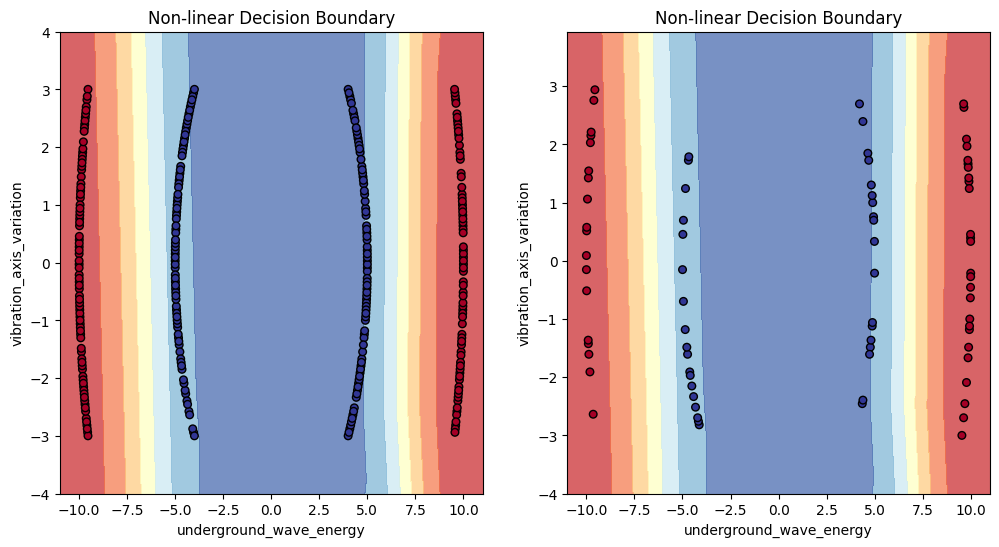

In [18]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()